In [2]:
import pandas as pd

In [8]:
data = pd.read_csv('./scenarios/comment/comparision.csv')

In [9]:
data

,algo,minTh,maxTh,demand_difference_mean,computational_time,consumed_charge
0,0,25,80,7.1000,0.000180,166.500
1,0,30,70,5.9000,0.000176,176.975
2,0,40,70,5.9250,0.000160,177.750
3,1,25,80,5.6750,0.228000,153.000
4,1,30,70,5.2625,0.183900,153.750
5,1,40,70,5.3500,0.202000,153.750
6,2,25,80,14.2000,0.000139,122.250
7,2,30,70,13.9125,0.000178,134.250
8,2,40,70,18.3875,0.000149,119.250


In [10]:
import matplotlib.pyplot as plt

In [11]:
plt.rcParams.update(
        {
            "figure.figsize": (6, 4),
            "font.size": 12,
            "lines.linewidth": 2,
            "lines.markersize": 6,
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "figure.dpi": 300,
        }
    )

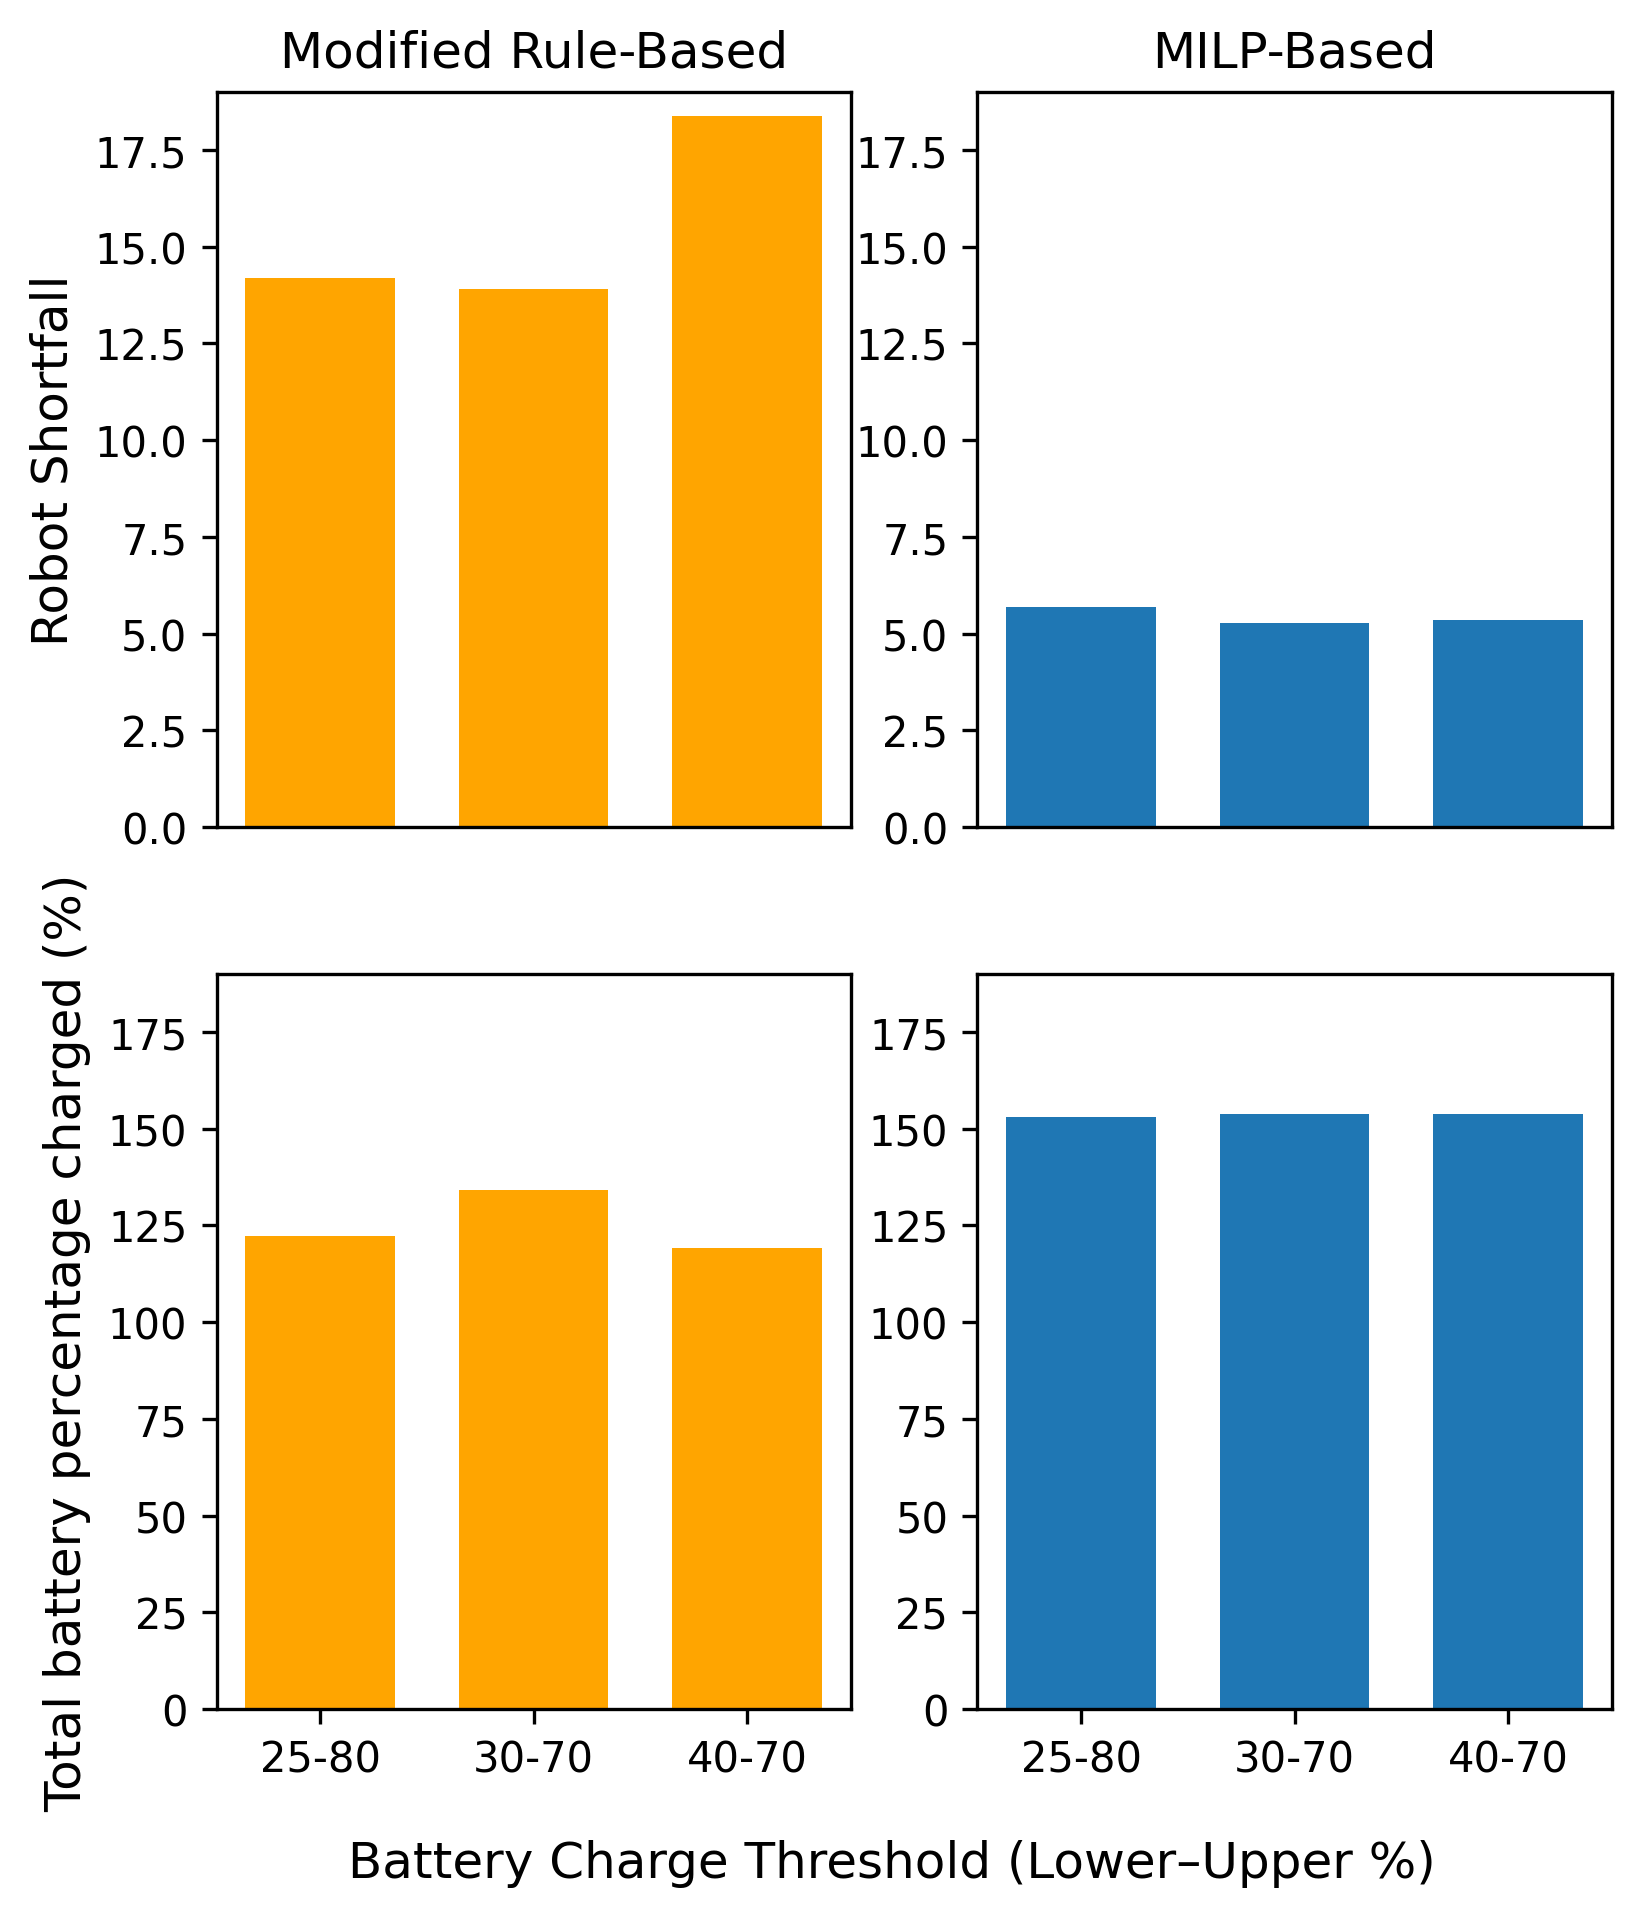

In [16]:
x = ['25-80', '30-70', '40-70']

fig,axes = plt.subplots(2,2,figsize=(6, 7))

axes[0,0].bar(x,data[data['algo'] == 2]['demand_difference_mean'], width=.7, color='orange')

axes[1,0].bar(x,data[data['algo'] == 2]['consumed_charge'], width=.7, color='orange')

axes[0,1].bar(x,data[data['algo'] == 1]['demand_difference_mean'], width=.7)
axes[1,1].bar(x,data[data['algo'] == 1]['consumed_charge'], width=.7)

axes[0,0].tick_params(labelbottom=False, bottom=False)
axes[0,1].tick_params(labelbottom=False, bottom=False)


# axes[0, 1].tick_params(axis='y', which='both', left=False, labelleft=False)
# axes[1, 1].tick_params(axis='y', which='both', left=False, labelleft=False)



axes[0, 0].set_ylim(0,19)
axes[0, 1].set_ylim(0,19)

axes[1, 0].set_ylim(0,190)
axes[1, 1].set_ylim(0,190)

axes[0,0].set_title("Modified Rule-Based")
axes[0,1].set_title("MILP-Based")

axes[0,0].set_ylabel("Robot Shortfall", ha='center')
axes[1,0].set_ylabel("Total battery percentage charged (%)", ha='center')


fig.text(0.5, 0.03, "Battery Charge Threshold (Lower–Upper %)", ha='center')
# axes[1,1].set_xlabel("Battery Charge Threshold (Lower-Upper %")

fig.savefig("varying_upper_limit.pdf")

In [48]:
from DemandSignal import DemandSignal, DemandType

ach = DemandSignal(DemandType.TRIANGULAR_STEP, 32, 35, 39, 3)
ach_signal = [ ach.get_demand_value(i) for i in range(3, 123, 3)]

not_ach = DemandSignal(DemandType.TRIANGULAR_STEP, 37, 40, 39, 3)
not_signal = [ not_ach.get_demand_value(i) for i in range(3, 123, 3)]

partial= DemandSignal(DemandType.TRIANGULAR_STEP, 34, 37, 39, 3)
partial_signal = [ partial.get_demand_value(i) for i in range(3, 123, 3)]

In [49]:
def get_working(data):
    return [ data[(milp_ach['time'] == i) & (data['mode'] == 1)]['mode'].sum() for i in range(3,123,3)]

def get_mean_absolute_difference(target, actual):
    return sum([abs(target[i] - actual[i]) for i in range(len(target))])/ len(target)
    
milp_ach = pd.read_csv("./output/scenario_1_milp/scenario_2_trapezoidal_achievable.csv")
milp_ach_demand_actual = get_working(milp_ach)
bcs_ach = pd.read_csv("./output/scenario_1_milp/scenario_2_bcs_trapezoidal_achievable_2.csv")
bcs_ach_demand_actual = get_working(bcs_ach)

milp_not = pd.read_csv("./output/scenario_1_milp/scenario_2_trapezoidal_not_achievable.csv")
milp_not_demand_actual = get_working(milp_not)
bcs_not = pd.read_csv("./output/scenario_1_milp/scenario_2_bcs_trapezoidal_not_achievable.csv")
bcs_not_demand_actual = get_working(bcs_not)

milp_partial = pd.read_csv("./output/scenario_2_trapezoidal_achievable_partial.csv")
milp_partial_demand_actual = get_working(milp_partial)
bcs_partial = pd.read_csv("./output/scenario_1_milp/scenario_2_bcs_trapezoidal_achievable_partial.csv")
bcs_partial_demand_actual = get_working(bcs_partial)


In [53]:
m_ach = get_mean_absolute_difference(ach_signal, milp_ach_demand_actual)
b_ach = get_mean_absolute_difference(ach_signal, bcs_ach_demand_actual)

m_not = get_mean_absolute_difference(not_signal, milp_not_demand_actual)
b_not = get_mean_absolute_difference(not_signal, bcs_not_demand_actual)

m_partial = get_mean_absolute_difference(partial_signal, milp_partial_demand_actual)
b_partial = get_mean_absolute_difference(partial_signal, milp_partial_demand_actual)

In [77]:
m = [m_ach+0.02, m_partial, m_not]
b = [b_ach, b_partial, b_not]
print(m,b)

[np.float64(0.02), np.float64(1.025), np.float64(3.7)] [np.float64(2.225), np.float64(1.025), np.float64(4.15)]


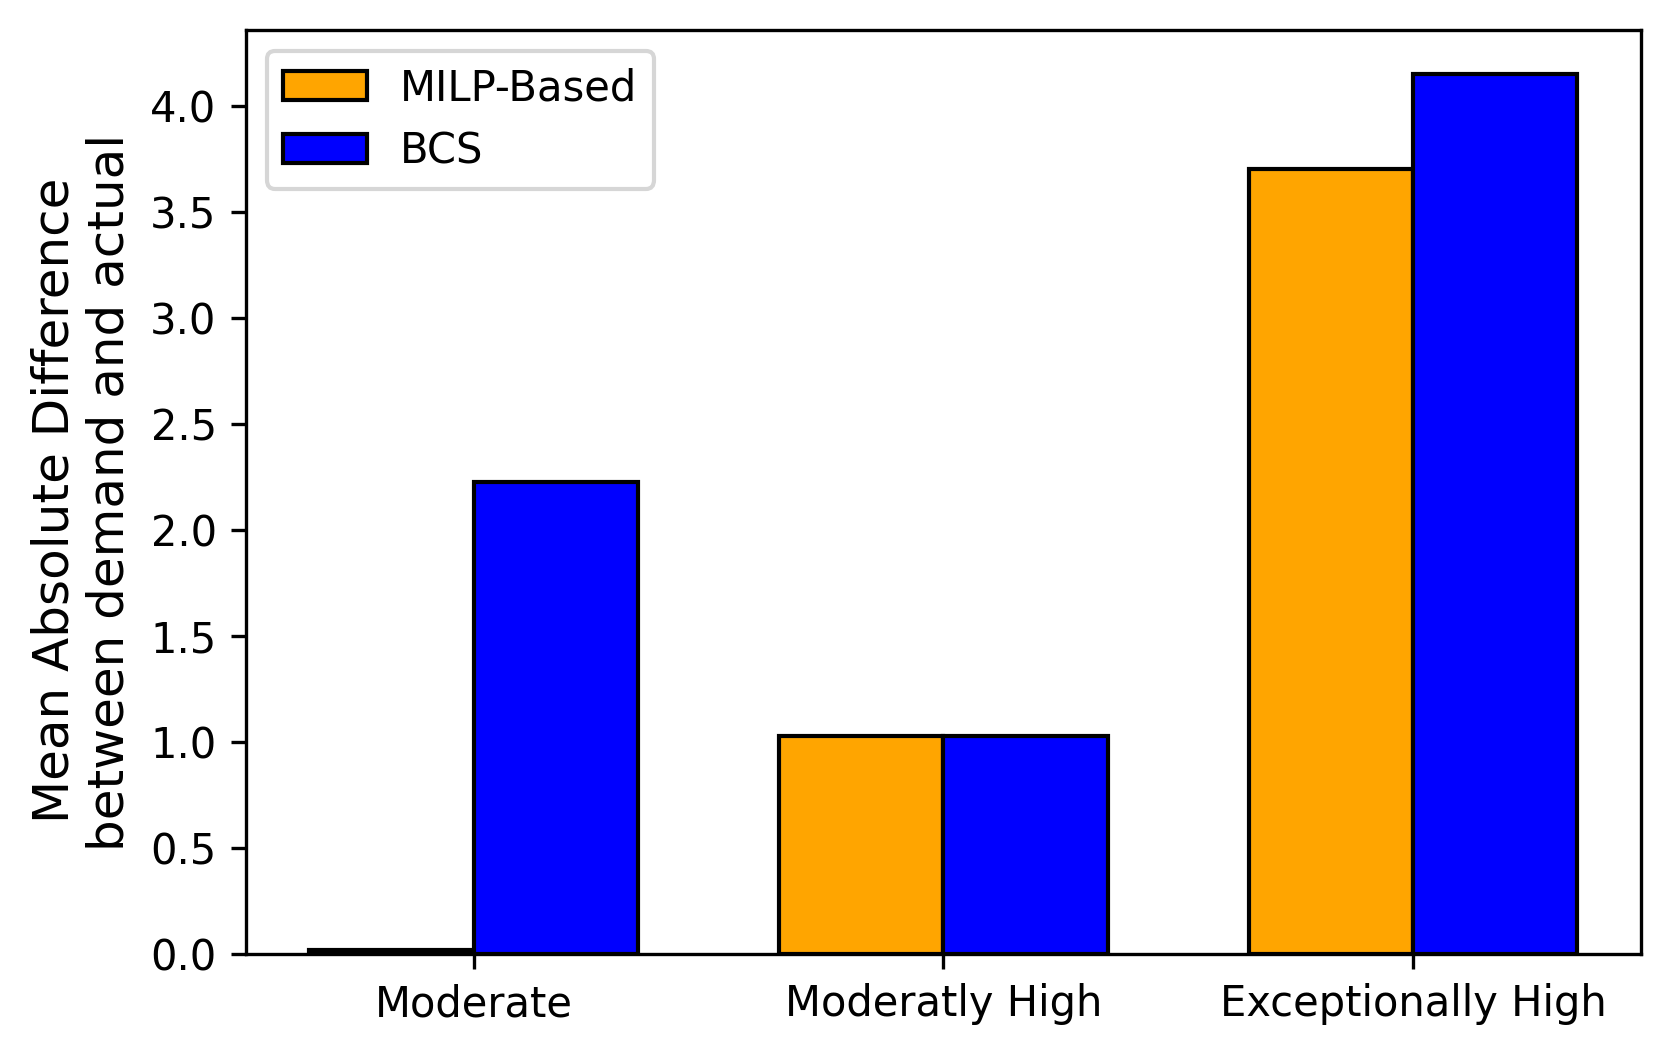

In [84]:
x = ['Moderate', 'Moderatly High', 'Exceptionally High']
ind = [0, 2, 4]

plt.bar([i - 0.35 for i in ind], m, width=.7, color="#FFA500",edgecolor='black', label='MILP-Based')
plt.bar([i + 0.35 for i in ind], b , width=.7, color="b",edgecolor='black', label='BCS')

plt.xticks(ind, x)

plt.ylabel('Mean Absolute Difference \nbetween demand and actual')

plt.legend()

plt.savefig("Comparison_MAD_between_MILP_and_BCS.pdf")

# plt.bar(, width=.7, color='orange')

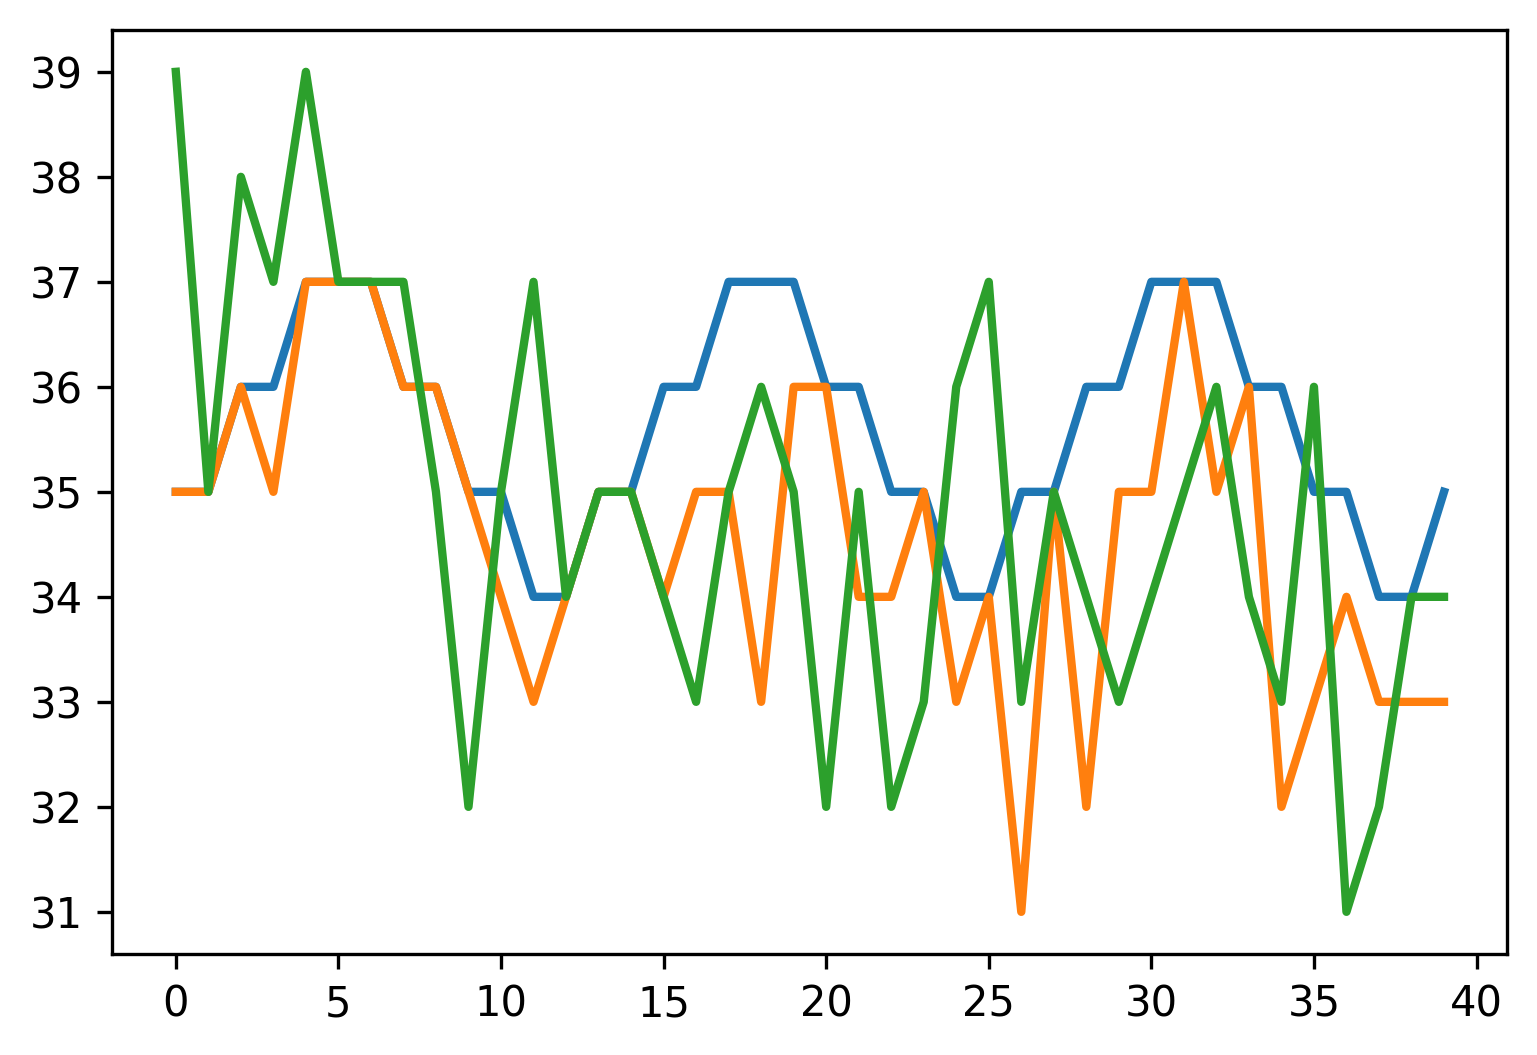

In [51]:
plt.plot(partial_signal)
plt.plot(milp_partial_demand_actual)
plt.plot(bcs_partial_demand_actual)

In [85]:
battery_data = pd.read_csv('./scenarios/comment/scenario_1_rule_based_nc_6_25_80.csv')

In [100]:
total_robot_per_interval = [len(battery_data[(battery_data['time'] == t) & (battery_data['mode'] != 3)]) for t in range(3,123,3)]


In [103]:
sum(total_robot_per_interval) / len(total_robot_per_interval)

38.9

In [106]:
total_robot_in_queue = [len(battery_data[(battery_data['time'] == t) & (battery_data['mode'] == 2)]) for t in range(3,123,3)]

In [110]:
battery_data[battery_data['mode'] == 2]

,time,sim2real,rid,cid,gid,mode,battery,critical
